## Libraries

### Install Libraries (`requirements.txt`)

We use some neat IPython features to write this automatically.

In [ ]:
%%writefile requirements.txt
numpy
matplotlib
importlib_resources
ipywidgets
gradio
scikit-learn

# tensorflow==2.17.*
# tensorflow-metal==1.1.*; sys_platform == 'darwin'

torch==2.11.*
torchvision==0.26.*
torchcodec==0.11.*
torchaudio==2.11.*
keras==3.*

In [ ]:
%pip install -r requirements.txt
%rm requirements.txt

### Load Libraries

In [1]:
%load_ext autoreload
%autoreload 1

from pathlib import Path
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import random

from sklearn.metrics import roc_curve, roc_auc_score
import gradio as gr

import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import torchaudio
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import keras
from keras import layers
from keras import ops

print(f"PyTorch {torch.__version__}")
print(f"Keras {keras.__version__} with backend {keras.backend.backend()}")

PyTorch 2.11.0
Keras 3.13.2 with backend torch


## Dataset

This first cell defines some path names.

In [2]:
# Path where the dataset is stored
data_dir = "/Users/tv/librispeech" ## CHANGE THIS

# See the website linked below for available splits
train_name = "train-clean-100"
test_name = "test-clean"
dev_name = "dev-clean"

# DON'T CHANGE
sample_rate = 16000 # DON'T CHANGE

### Download

The following cell downloads the sets defined above (in `train_name`, `test_name` and `dev_name`) into `data_dir`,
from <https://www.openslr.org/12>.

The downloaded archive is structured like `LibriSpeech/<dataset>/<speaker>/<chapter>/<file>.flac`. This function also takes care to encode
and reorganize that into `<dataset>/<speaker>/<file>.wav` (we don't care about chapter structure).

In [3]:
# Check dependencies
import shutil
for requirement in ["curl", "tar", "grep", "ffmpeg"]:
    if not shutil.which(requirement):
        raise f"Dependency {requirement} not found!"

def ensure_set(name: str):
    """Ensures that a split of LibriSpeech is available."""
    
    basepath = Path(data_dir)
    # Expected directory for this split
    set_dir = basepath.joinpath(name)
    # Archive path
    tar = basepath.joinpath(name + ".tar.gz")
    # Ensure the main data directory exists
    basepath.mkdir(exist_ok=True, parents=True)

    if set_dir.exists():
        print(f"Set {name} already found")
        return

    # Download provided archive from the web using cURL
    if not tar.exists():
        print(f"Downloading LibriSpeech {name}...")
        url = "https://openslr.trmal.net/resources/12/" + name + ".tar.gz"
        !curl -Lo {tar.absolute()} {url}

    # Extract downloaded archive
    print(f"Extracting LibriSpeech {name}")
    set_dir.mkdir()
    # This grep pattern extracts the first-level directories after the split name,
    # which correspond to speaker IDs.
    # I❤️IPython
    speakers = !tar -tf {tar.absolute()} | grep '.*/'{name}'/[[:digit:]]*/$'
    for speaker in speakers:
        # Path to the speaker *within the archive*
        sp_in_tar = Path(speaker)
        # Path to the speaker directory
        speaker_dir = set_dir.joinpath(sp_in_tar.name)
        speaker_dir.mkdir()
        
        print(f"Extracting speaker {sp_in_tar.name}")
        # This pattern extracts all .flac files from the speaker directory
        # --strip-components 4 is used to remove leading directories (chapter information etc.)
        # as we already make sure the files are extracted to the speaker directory using -C
        !tar -C {speaker_dir.absolute()} --strip-components 4 -xzf {tar.absolute()} {sp_in_tar}'/**/*.flac'

        # # WAV Conversion, also ensures the sample rate is correct
        # for sample in speaker_dir.glob("*.flac"):
        #     !ffmpeg -loglevel error -y -i {sample.absolute()} -ar {sample_rate} {sample.with_suffix(".wav").absolute()}
        #     # Remove original .flac
        #     sample.unlink()

    # Remove archive
    tar.unlink()

print("Downloading dataset (LibriSpeech)")
ensure_set(train_name)
ensure_set(dev_name)
ensure_set(test_name)
print("Done!")

Set train-clean-100 already found
Set dev-clean already found
Set test-clean already found
Done!


### Setup

This just traverses a provided directory and reads audio files within (and trims/crops/pads them).

This is saved to an external file, because the parallel PyTorch workers need to access it later.

In [ ]:
%%writefile dataset.py
import os
import torch
import torchaudio
import random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import itertools
import functools

def decode_one_file_nocache(file, length_samples, sample_rate):
    # Decode the file
    audio, rate = torchaudio.load(file)

    # Resample if necessary
    if sample_rate is not None and rate != sample_rate:
        audio = torchaudio.functional.resample(audio, rate, sample_rate)

    # Downmix stereo
    if audio.shape[0] > 1: audio = torch.mean(audio, dim=0)
    # Remove the unnecessary channel dimension (in LibriSpeech always 1)
    else: audio = audio.squeeze()

    # Pad using repeat
    audio_length = audio.shape[0]

    if audio_length < length_samples:
        repeats = (length_samples // audio_length) + 1
        audio = audio.repeat(repeats)
        audio = audio[:length_samples]

    return audio

def read_and_crop_direct(audio, length_samples):
    # Random crop
    audio_length = audio.shape[0]
    if audio_length > length_samples:
        max_start = audio_length - length_samples
        start = torch.randint(0, max_start + 1, (1,)).item()
        audio = audio[start : start+length_samples]

    return audio

@functools.lru_cache(maxsize=1000)
def decode_one_file(file, length_samples, sample_rate):
    return decode_one_file_nocache(file, length_samples, sample_rate)

# Crop audio file to the correct length (randomly)
def read_and_crop(file, length_samples, sample_rate):
    audio = decode_one_file(file, length_samples, sample_rate)
    return read_and_crop_direct(audio, length_samples)

# Map file paths to actual audio dynamically
# the files are cropped randomly every epoch, acting as augmentation
class TripleAudioDataset(Dataset):
    def __init__(self, anchor, positive, negative, labels, sample_rate, length_samples):
        self.anchor = anchor
        self.positive = positive
        self.negative = negative
        self.labels = labels
        self.sample_rate = sample_rate
        self.length_samples = length_samples

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Read and process the audio pairs
        audio_anchor = read_and_crop(self.anchor[idx], self.length_samples, self.sample_rate)
        audio_positive = read_and_crop(self.positive[idx], self.length_samples, self.sample_rate)
        audio_negative = read_and_crop(self.negative[idx], self.length_samples, self.sample_rate)

        # Return a tuple of inputs and the label
        return (audio_anchor, audio_positive, audio_negative), self.labels[idx]

# Traverse directory structure to generate dataset for a Siamese network with contrastive loss
def triple_ds(directory, length_samples, sample_rate=16000, batch_size=32, max_triplets_per_speaker=1000, seed=None):
    if seed:
        random.seed(seed)
        torch.manual_seed(seed)

    directory = Path(directory)

    # First-level directories correspond to speakers
    speaker_dirs = [d for d in directory.glob("*") if d.is_dir()]
    # Map of speaker name => file list
    speaker_to_files = {}

    # Populate speaker_to_files
    for d in speaker_dirs:
        files = [str(p) for p in d.glob("*.flac")]
        if len(files) >= 2:
            speaker_to_files[d.name] = files
        else:
            print("Warning: discarding speaker", d.name)

    if not speaker_to_files: raise ValueError("Not enough data")

    # Python crashes if I don't do this
    speakers = list(speaker_to_files.keys())
    
    # This will become the actual dataset
    anchor_list = []
    positive_list = []
    negative_list = []

    for speaker in speakers:
        files = speaker_to_files[speaker]
        positive_pairs = list(itertools.combinations(files, 2))
        random.shuffle(positive_pairs)

        # Truncate if necessary
        if max_triplets_per_speaker:
            positive_subset = positive_pairs[:max_triplets_per_speaker]
        else: positive_subset = positive_pairs

        # These are all positive pairs
        for anchor, positive in positive_subset:
            anchor_list.append(anchor)
            positive_list.append(positive)

            # Find a negative
            other_speaker = random.choice([s for s in speakers if s != speaker])
            negative = random.choice(speaker_to_files[other_speaker])
            negative_list.append(negative)

    # Not actually used for anything
    zero_labels = torch.zeros(len(anchor_list), dtype=torch.float32)

    dataset = TripleAudioDataset(anchor_list, positive_list, negative_list, zero_labels, sample_rate, length_samples)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=os.cpu_count(),
        prefetch_factor=2,
        pin_memory=torch.cuda.is_available(), # Compatibility with nVidia
    )

    return loader

class DualAudioDataset(Dataset):
    def __init__(self, path_a, path_b, labels, sample_rate, length_samples):
        self.path_a = path_a
        self.path_b = path_b
        self.labels = labels
        self.sample_rate = sample_rate
        self.length_samples = length_samples

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Read and process the audio pairs
        audio_a = read_and_crop(self.path_a[idx], self.length_samples, self.sample_rate)
        audio_b = read_and_crop(self.path_b[idx], self.length_samples, self.sample_rate)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        # Return a tuple of inputs and the label
        return (audio_a, audio_b), label

def dual_ds(directory, length_samples, sample_rate=16000, batch_size=32, max_pairs_per_speaker=1000, seed=None):
    if seed:
        random.seed(seed)
        torch.manual_seed(seed)

    directory = Path(directory)

    # First-level directories correspond to speakers
    speaker_dirs = [d for d in directory.glob("*") if d.is_dir()]
    # Map of speaker name => file list
    speaker_to_files = {}

    # Populate speaker_to_files
    for d in speaker_dirs:
        files = [str(p) for p in d.glob("*.flac")]
        if len(files) >= 2:
            speaker_to_files[d.name] = files
        else:
            print("Warning: discarding speaker", d.name)

    if not speaker_to_files: raise ValueError("Not enough data")

    # Python crashes if I don't do this
    speakers = list(speaker_to_files.keys())
    
    # This will become the actual dataset
    a_list = []
    b_list = []
    label_list = []

    for speaker in speakers:
        files = speaker_to_files[speaker]
        positive_pairs = list(itertools.combinations(files, 2))
        random.shuffle(positive_pairs)

        # Truncate if necessary
        if max_pairs_per_speaker:
            positive_subset = positive_pairs[:max_pairs_per_speaker]
        else: positive_subset = positive_pairs

        # These are all positive pairs
        for a, b in positive_subset:
            a_list.append(a)
            b_list.append(b)
            label_list.append(1.0)

            # Find a negative            
            other_speaker = random.choice([s for s in speakers if s != speaker])
            neg_a = random.choice(files)
            neg_b = random.choice(speaker_to_files[other_speaker])
            
            # Append the negative pair
            a_list.append(neg_a)
            b_list.append(neg_b)
            label_list.append(0.0)

    dataset = DualAudioDataset(a_list, b_list, label_list, sample_rate, length_samples)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=os.cpu_count(),
        prefetch_factor=2,
        pin_memory=torch.cuda.is_available(), # Compatibility with nVidia
    )

    return loader


Overwriting dataset.py


In [ ]:
%aimport dataset
from dataset import TripleAudioDataset, triple_ds, DualAudioDataset, dual_ds, decode_one_file_nocache, read_and_crop_direct

#### Log-Mel Spectrograms

The [mel scale](https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53) maps frequencies to intervals close to humans perceive them (i.e. logarithmically).

$$ \operatorname{mel}(f) = 2595 \log_{10} \left(1 + \frac{f}{700} \right) $$

The log-mel scale, that is, taking another logarithm, has been found to be useful in speaker recognition.

We define here a custom layer, named `LogMelSpectrogram`, which transforms the input batch into log-mel spectrograms.

In [6]:
# Convert raw samples to a log-mel spectrogram
@keras.saving.register_keras_serializable()
class LogMelSpectrogram(layers.Layer):
    sample_rate: int
    fft_size: int
    step_size: int
    num_mel_bins: int
    
    # fft_size - bigger gets us more accurate frequencies but less accurate timing
    def __init__(self, sample_rate, fft_size=1024, step_size=128, num_mel_bins=64, **kwargs):
        super().__init__(**kwargs)
        self.sample_rate = sample_rate
        self.fft_size = fft_size
        self.step_size = step_size
        self.num_mel_bins = num_mel_bins

    def build(self, input_shape):
        # Compute the weights once
        mel_weights = torchaudio.functional.melscale_fbanks(
            n_freqs=self.fft_size // 2 + 1,
            f_min=20.0,
            f_max=7600.0,
            n_mels=self.num_mel_bins,
            sample_rate=self.sample_rate,
            norm="slaney",
        )

        # Register the mel weights as a Keras non-trainable weight.
        # This ensures correct movement between CPU/GPU
        self.mel_weights = self.add_weight(
            name="mel_weights",
            shape=mel_weights.shape,
            initializer=keras.initializers.Constant(mel_weights.numpy()),
            trainable=False,
        )
        
        super().build(input_shape)

    def call(self, batch):
        # Remove unnecessary channels
        if len(batch.shape) == 3 and batch.shape[-1] == 1:
            waveforms = ops.squeeze(batch, axis=-1)
        else: waveforms = batch

        # DFT
        stft = torch.stft(
            waveforms,
            n_fft=self.fft_size,
            hop_length=self.step_size,
            win_length=self.fft_size,
            window=torch.hann_window(self.fft_size, device=waveforms.device),
            center=False, # Don't pad end
            return_complex=True,
        )

        # Convert from (..., bins, time) to (..., time, bins)
        stft = ops.transpose(stft, axes=(0, 2, 1))

        # Strength of frequency is strictly nonnegative
        spectrograms = ops.abs(stft)
        mel_spectros = ops.tensordot(spectrograms, self.mel_weights, axes=1)
        # We don't want the log to be zero, so we add epsilon
        log_mels = ops.log(mel_spectros + keras.backend.epsilon())
        return ops.expand_dims(log_mels, axis=-1)
    
    def compute_output_shape(self, input_shape):
        batch_size = input_shape[0]
        input_length = input_shape[1]

        # Very similar calculation for a convolution layer
        if input_length is None: num_frames = None
        else: num_frames = (input_length - self.fft_size) // self.step_size + 1

        return (batch_size, num_frames, self.num_mel_bins, 1)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "sample_rate": self.sample_rate,
            "fft_size": self.fft_size,
            "step_size": self.step_size,
            "num_mel_bins": self.num_mel_bins,
        })
        return config

#### Datasets

In [ ]:
# Hyperparameters
batch_size = 32
length_seconds = 2
seed = 1337

train_ds = triple_ds(
    Path(data_dir).joinpath(train_name),
    batch_size=batch_size,
    sample_rate=sample_rate,
    length_samples=length_seconds*sample_rate,
    max_triplets_per_speaker=150,
    seed=seed
)

test_ds = triple_ds(
    Path(data_dir).joinpath(test_name),
    batch_size=batch_size,
    sample_rate=sample_rate,
    length_samples=length_seconds*sample_rate,
    max_triplets_per_speaker=None,
    seed=seed
)

dev_ds = triple_ds(
    Path(data_dir).joinpath(dev_name),
    batch_size=batch_size,
    sample_rate=sample_rate,
    length_samples=length_seconds*sample_rate,
    max_triplets_per_speaker=None,
    seed=seed
)

dev_dual_ds = dual_ds(
    Path(data_dir).joinpath(dev_name),
    batch_size=batch_size,
    sample_rate=sample_rate,
    length_samples=length_seconds*sample_rate,
    max_triplets_per_speaker=None,
    seed=seed
)

#### Examples

In [8]:
from IPython.display import Audio

for i in range(5):
    print(i)
    ((anchor, positive, negative), label) = train_ds.dataset[i]
    display(Audio(anchor, rate=sample_rate), Audio(positive, rate=sample_rate), Audio(negative, rate=sample_rate))

# for (x, label) in train_ds.take(1):
#     (file_a, file_b) = x
#     for i in range(5):
#         print("Positive pair" if label[i] == 1 else "Negative pair")
#         display(Audio(file_a[i], rate=sample_rate), Audio(file_b[i], rate=sample_rate))


0


1


2


3


4


## Models

### Helper Functions

The following functions define a siamese network and triplet loss (contrastive loss left in from a previous version).

$$
\mathcal{L}_{\text{triplet}}(a, p, n) = \sum_{i=1}^n \max\{ \lVert a^{(i)} - p^{(i)} \rVert^2 - \lVert a^{(i)} - n^{(i)} \rVert^2 + \mathit{margin}, 0 \}
$$

Contrastive loss is also defined here, from a previous version.

$$
\mathcal{L}_{\text{contrastive}}(y, d) = \sum_{i=1}^p y^{(i)} (d^{(i)})^2 + (1 - y^{(i)}) \max\{ \mathit{margin} - d^{(i)}, 0 \}^2
$$


In [9]:
# Create a siamese network from a given model
def siamese_from_model(model, input_shape):
    anchor_input = layers.Input(shape=input_shape, name="anchor")
    positive_input = layers.Input(shape=input_shape, name="positive")
    negative_input = layers.Input(shape=input_shape, name="negative")

    embedding_a = model(anchor_input)
    embedding_p = model(positive_input)
    embedding_n = model(negative_input)

    output = ops.stack([embedding_a, embedding_p, embedding_n], axis=1)

    return keras.Model(inputs=[anchor_input, positive_input, negative_input], outputs=output, name="siamese_" + model.name)

def dual_siamese_from_model(model, input_shape):
    input_a = layers.Input(shape=input_shape, name="a")
    input_b = layers.Input(shape=input_shape, name="b")

    embedding_a = model(input_a)
    embedding_b = model(input_b)

    dist = ops.sqrt(ops.sum(ops.square(embedding_a - embedding_b), axis=1))

    return keras.Model(inputs=[input_a, input_b], outputs=dist, name="siamese2_" + model.name)

def final_predictor_from_model(model, input_shape, margin):
    input_a = layers.Input(shape=input_shape, name="a")
    input_b = layers.Input(shape=input_shape, name="b")

    dist = dual_siamese_from_model(model, input_shape)((input_a, input_b))

    prediction = (dist < margin).cast("float32")

    return keras.Model(inputs=[input_a, input_b], outputs=prediction, name="predictor_" + model.name)

@keras.saving.register_keras_serializable()
class ContrastiveLoss(keras.Loss):
    def __init__(self, margin=1.0, **kwargs):
        super().__init__(**kwargs)
        self.margin = margin

    def call(self, y_true, y_pred):
        # Notice: y_pred is the Euclidean distance
        y = ops.cast(y_true, dtype=y_pred.dtype)
        loss_same = y * ops.square(y_pred)
        loss_diff = (1.0 - y) * ops.square(ops.maximum(self.margin - y_pred, 0.0))
        return ops.mean(loss_same + loss_diff)

    def get_config(self):
        config = super().get_config()
        config.update({
            "margin": self.margin
        })
        return config

@keras.saving.register_keras_serializable()
class TripletLoss(keras.Loss):
    def __init__(self, margin=0.2, **kwargs):
        super().__init__(**kwargs)
        self.margin = margin

    def call(self, y_true, y_pred):
        # y_true is always 0,
        # y_pred is (anchor, positive, negative)

        anchor = y_pred[:, 0, :]
        positive = y_pred[:, 1, :]
        negative = y_pred[:, 2, :]

        dist_pos = ops.sum(ops.square(anchor - positive), axis=1)
        dist_neg = ops.sum(ops.square(anchor - negative), axis=1)

        return ops.mean(ops.maximum(dist_pos - dist_neg + self.margin, 0.0))

    def get_config(self):
        config = super().get_config()
        config.update({
            "margin": self.margin
        })
        return config

Some callbacks to optimize the training process.

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, start_from_epoch=5),
    keras.callbacks.ReduceLROnPlateau()
]

And global constants

In [11]:
audio_input_shape=(length_seconds * sample_rate, 1)
spectro_shape = LogMelSpectrogram(sample_rate=sample_rate).compute_output_shape((batch_size,) + audio_input_shape)

L2-Normalization layer:

$$
\mathrm{Normalize}(x)^{(i)} = \frac{x^{(i)}}{\lVert x^{(i)} \rVert_2}
$$

In [12]:
@keras.saving.register_keras_serializable()
class L2Normalize(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        super().build(input_shape)

    def call(self, batch):
        return F.normalize(batch, p=2.0, dim=1)

    def compute_output_shape(self, input_shape):
        return input_shape

A residual blocks takes the input through two paths:
- Convolution → BatchNorm → ReLU → Convolution
- If necessary to expand the size, Convolution with 1x1 kernel → BatchNorm

And adds the result. This makes it simple to learn to "do nothing": learn zeroes in the first path and all ones in the second path.

In the following cell both 2D and 1D versions are defined.

In [13]:
@keras.saving.register_keras_serializable()
class ResidualBlock2D(layers.Layer):
    def __init__(self, filters, kernel_size=(3, 3), strides=(1, 1), **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.strides = strides

        self.conv1 = layers.Conv2D(filters, kernel_size, strides=strides, padding="same")
        self.bn1 = layers.BatchNormalization()
        self.relu1 = layers.ReLU()

        self.conv2 = layers.Conv2D(filters, kernel_size, strides=(1, 1), padding="same")
        self.bn2 = layers.BatchNormalization()

        self.add = layers.Add()
        self.relu2 = layers.ReLU()

    def build(self, input_shape):
        channels = input_shape[-1]
        needs_projection = (channels != self.filters) or (self.strides != (1, 1) and self.strides != 1)
        if needs_projection:
            self.shortcut_conv = layers.Conv2D(self.filters, (1, 1), strides=self.strides, padding="same")
            self.shortcut_bn = layers.BatchNormalization()
        else:
            self.shortcut_conv = None
            self.shortcut_bn = None

        super().build(input_shape)

    def call(self, inputs, training=False):
        # Main path
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        if self.shortcut_conv is None:
            shortcut = inputs
        else:
            shortcut = self.shortcut_conv(inputs)
            shortcut = self.shortcut_bn(shortcut, training=training)

        x = self.add([x, shortcut])
        return self.relu2(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "strides": self.strides
        })
        return config

@keras.saving.register_keras_serializable()
class ResidualBlock1D(layers.Layer):
    def __init__(self, filters, kernel_size=3, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.strides = strides

        self.conv1 = layers.Conv1D(filters, kernel_size, strides=strides, padding="same")
        self.bn1 = layers.BatchNormalization()
        self.relu1 = layers.ReLU()

        self.conv2 = layers.Conv1D(filters, kernel_size, strides=1, padding="same")
        self.bn2 = layers.BatchNormalization()

        self.add = layers.Add()
        self.relu2 = layers.ReLU()

    def build(self, input_shape):
        channels = input_shape[-1]
        needs_projection = channels != self.filters or self.strides != 1
        if needs_projection:
            self.shortcut_conv = layers.Conv1D(self.filters, 1, strides=self.strides, padding="same")
            self.shortcut_bn = layers.BatchNormalization()
        else:
            self.shortcut_conv = None
            self.shortcut_bn = None

        super().build(input_shape)

    def call(self, inputs, training=False):
        # Main path
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        if self.shortcut_conv is None:
            shortcut = inputs
        else:
            shortcut = self.shortcut_conv(inputs)
            shortcut = self.shortcut_bn(shortcut, training=training)

        x = self.add([x, shortcut])
        return self.relu2(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "strides": self.strides
        })
        return config

### Plotting

This function simply plots the training loss and validation loss against epochs.

In [14]:
def plot_history(history):
    fig, ax = plt.subplots(1)
    ax.plot(history.history["loss"], label="Train")
    ax.plot(history.history["val_loss"], label="Dev")
    ax.set_title("Loss")
    ax.set_ylabel("Loss")
    ax.set_xlabel("Epoch")
    ax.legend()
    plt.show()

The following cell defines functions to calculate commonly used metrics. The calculations are on a dataset of pairs rather than triplets.

**FAR and FRR**

False Acceptance Rate and False Rejection Rate count the share of wrongly identified and wrongly misidentified samples, respectively.

Let $P = \{ i \mid y^{(i)} = 1 \}$ denote the set of all positive samples (same speaker) and $N = \{ i \mid y^{(i)} = 0 \}$ the set of all negative samples (different speaker),
$A = \{ i \mid \hat{y}^{(i)} < \mathit{margin} \}$ the set of accepted samples (thought to match in speaker) and $R = \{ i \mid \hat{y}^{(i)} > \mathit{margin} \}$ the set of rejected samples (thought to differ in speaker). Then simply

$$
\begin{align*}
\mathrm{FAR}(y,\hat{y},\mathit{margin}) &= \frac{\lvert N \cap A \rvert}{\lvert N \rvert} \\

\mathrm{FRR}(y,\hat{y},\mathit{margin}) &= \frac{\lvert P \cap R \rvert}{\lvert P \rvert}
\end{align*}
$$

**ERR**

Equal Error Rate is the threshold/margin where FAR=FRR (or closest), which is the best margin to operate at.

$$
\mathrm{ERR}(y,\hat{y}) = \argmin_{\mathit{margin}} ~ \{ \left\lvert \mathrm{FAR}(y,\hat{y},\mathit{margin}) - \mathrm{FRR}(y,\hat{y},\mathit{margin}) \right\rvert \}
$$

**AUC / ROC**

Area Under the Curve measures the overall performance. Define the true acceptance rate as $\mathrm{TAR} = 1 - \mathrm{FRR} = \lvert P \cap A \rvert \big/ \lvert P \rvert$ and construct a graph of $\mathrm{TAR}$ vs. $\mathrm{FAR}$ (varying $\mathit{margin}$, noting that both are monotonically increasing with respect to $\mathit{margin}$ and must intersect at $0\%$ and $100\%$). This is called the Receiver Operating Characteristic (ROC) graph, and the area under it (or the discrete version thereof) is the AUC metric.

$$
\mathrm{AUC}(a,b,y,\hat{y}) = \int_0^1 \mathrm{TAR} ~ d\,\mathrm{FAR} = \int_0^2 \mathrm{TAR} \frac{\partial \mathrm{FAR}}{\partial \mathit{margin}} ~ d\mathit{margin}
$$

In [15]:
def evaluate_accuracy(model, dual_ds):
    y_true = []
    dists = []

    # Collect true labels and distances
    for (chunk_a, chunk_b), labels in dual_ds:
        embedding_a = model.predict(chunk_a, verbose=0)
        embedding_b = model.predict(chunk_b, verbose=0)

        distances = np.sqrt(np.sum(np.square(embedding_a - embedding_b), axis=1))
        dists.extend(distances)
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    dists = np.array(dists)

    # scikit-learn wants higher -> more similar, which is the opposite
    # of our sytsem.
    similarities = -dists

    # This gives us the FPR (=FAR) and TPR (=1-FRR) for various thresholds
    fpr, tpr, thresholds = roc_curve(y_true, similarities)
    # Coutn the area under the curve
    roc_auc = roc_auc_score(y_true, similarities)

    # FNR (=FRR)
    fnr = 1 - tpr

    # Find the threshold that minimizes the difference, i.e. brings FAR and FRR
    # closest together,
    eer_index = np.nanargmin(np.absolute(fnr - fpr))
    # its value,
    eer = fpr[eer_index]

    # and its location.
    optimal_threshold = -thresholds[eer_index]

    print(f"Area Under Curve (AUC): {roc_auc:.4f}")
    print(f"Equal Error Rate (EER): {eer:.4%}")
    print(f"Optimal Distance Threshold: {optimal_threshold:.4f}")

    return eer, roc_auc, optimal_threshold, (fpr, tpr)

def plot_roc_curve(fpr, tpr, roc_auc):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Acceptance Rate (FAR)")
    plt.ylabel("True Positive Rate (1 - FRR)")
    plt.title("Receiver Operating Characteristic")
    plt.legend(loc="lower right")
    plt.show()

### Gradio

In [16]:
%load_ext gradio

def model_ui(model, margin, length_samples, sample_rate):
    def predict(path_a, path_b):
        if path_a is None or path_b is None:
            return "Upload or record both audio clips."
        if model is None:
            return "No model provided."

        audio_a = read_and_crop_direct(decode_one_file_nocache(path_a, length_samples, sample_rate), length_samples)
        audio_b = read_and_crop_direct(decode_one_file_nocache(path_b, length_samples, sample_rate), length_samples)

        audio_a = audio_a.reshape((1,) + audio_a.shape)
        audio_b = audio_b.rehspae((1,) + audio_b.shape)

        emb_a = model(audio_a).squeeze()
        emb_b = model(audio_b).squeeze()

        dist = ops.sqrt(ops.sum(ops.square(emb_a - emb_b)))

        if dist < margin:
            conclusion = "✅ **Same Speaker**"
        else:
            conclusion = "❌ **Different Speakers**"

        # Format the output beautifully
        result = f"{conclusion}\n\n**Euclidean Distance:** {distance:.4f}\n*(Margin: {margin})*"
        print(result)
        return result

    with gr.Blocks() as interface:
        gr.Markdown("# Speaker Verification")
        gr.Markdown("Upload or record two audio clips to see whether the model thinks that they are spoken by the same person.")

        with gr.Row():
            with gr.Column():
                audio_a = gr.Audio(type="filepath", label="Clip A")
            with gr.Column():
                audio_b = gr.Audio(type="filepath", label="Clip B")

        with gr.Row():
            button = gr.Button("Check", variant="primary")

        with gr.Row():
            output = gr.Markdown(label="Result", show_label=True)

        button.click(fn=predict, inputs=[audio_a, audio_b], outputs=output)

        return interface

### 1D CNN on Raw Audio

This uses a very aggressive initial convolution layer to get the size down. Afterwards, the standard sequence of conv -> batchnorm -> maxpool is followed with some dense layers at the end.

In [17]:
audio_cnn = keras.Sequential([
  layers.Input(shape=audio_input_shape),
  layers.Conv1D(32, sample_rate // 8, strides=sample_rate // 600, activation="relu"),
  layers.Conv1D(32, 5, activation="relu", padding="same"),
  layers.BatchNormalization(),
  
  ResidualBlock1D(32, strides=2),
  ResidualBlock1D(64),
  ResidualBlock1D(64, strides=2),
  ResidualBlock1D(64, strides=2),
  ResidualBlock1D(64),
  ResidualBlock1D(128, strides=2),
  ResidualBlock1D(128),
  ResidualBlock1D(128, strides=2),
  ResidualBlock1D(256, strides=2),
  ResidualBlock1D(256),
  ResidualBlock1D(256, strides=2),
  ResidualBlock1D(512, strides=2),
  ResidualBlock1D(512),
  ResidualBlock1D(512, strides=2),

  layers.Flatten(),
  layers.Dropout(0.2),
  layers.Dense(2048, activation="relu"),
  L2Normalize(),
], name="cnn_1d_on_audio")

audio_cnn.summary()

Model: "cnn_1d_on_audio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1154, 32)       │        64,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1154, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1154, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d                │ (None, 577, 32)        │         7,648 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_1              │ (None, 577, 64)        │        21,440 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_2              │ (None, 289, 64)        │        29,632 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_3              │ (None, 145, 64)        │        29,632 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_4              │ (None, 145, 64)        │        25,216 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_5              │ (None, 73, 128)        │        83,840 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_6              │ (None, 73, 128)        │        99,584 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_7              │ (None, 37, 128)        │       116,608 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_8              │ (None, 19, 256)        │       331,520 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_9              │ (None, 19, 256)        │       395,776 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_10             │ (None, 10, 256)        │       462,592 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_11             │ (None, 5, 512)         │     1,318,400 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_12             │ (None, 5, 512)         │     1,577,984 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_13             │ (None, 3, 512)         │     1,842,688 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,559,648 (36.47 MB)

 Trainable params: 9,543,648 (36.41 MB)

 Non-trainable params: 16,000 (62.50 KB)

#### Training

In [18]:
siamese_audio_cnn = siamese_from_model(audio_cnn, audio_input_shape)

siamese_audio_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=TripletLoss(margin=0.2))
history = siamese_audio_cnn.fit(
    train_ds,
    epochs=30,
    callbacks=callbacks,
    validation_data=dev_ds,
)

Epoch 1/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2723s 2s/step - loss: 0.1063 - val_loss: 0.0795 - learning_rate: 0.0010
Epoch 2/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2687s 2s/step - loss: 0.0816 - val_loss: 0.0677 - learning_rate: 0.0010
Epoch 3/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2743s 2s/step - loss: 0.0664 - val_loss: 0.0637 - learning_rate: 0.0010
Epoch 4/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2673s 2s/step - loss: 0.0592 - val_loss: 0.0595 - learning_rate: 0.0010
Epoch 5/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2669s 2s/step - loss: 0.0559 - val_loss: 0.0554 - learning_rate: 0.0010
Epoch 6/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2674s 2s/step - loss: 0.0484 - val_loss: 0.0576 - learning_rate: 0.0010
Epoch 7/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2692s 2s/step - loss: 0.0441 - val_loss: 0.0548 - learning_rate: 0.0010
Epoch 8/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2673s 2s/step - loss: 0.0414 - val_loss: 0.0544 - learning_rate: 0.0010
Epoch 9/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2684s 2s/step - loss: 0.0387 - val_loss: 0.046

Plot margin/accuracy and epochs/loss.

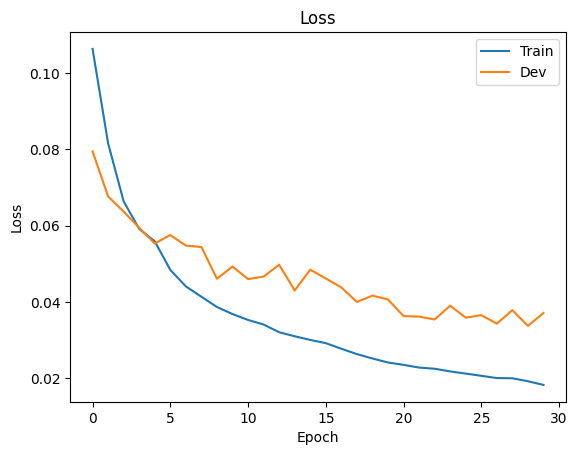

Area Under Curve (AUC): 0.9361
Equal Error Rate (EER): 12.8710%
Optimal Distance Threshold: 0.7322


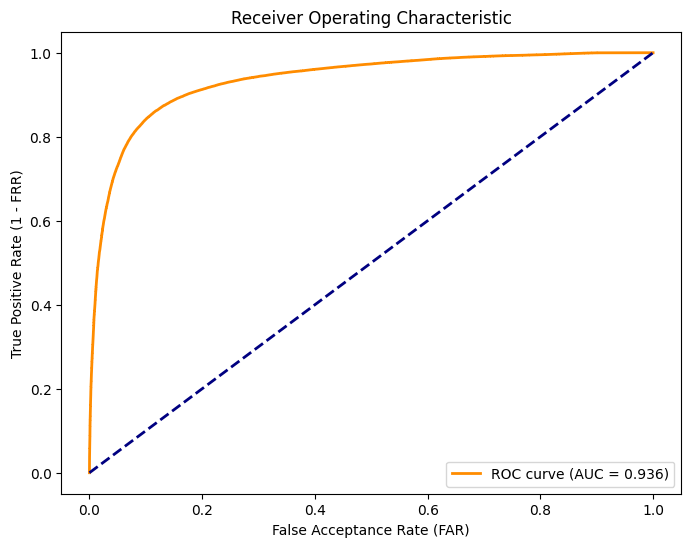

In [21]:
plot_history(history)
eer, auc_score, optimal_margin, (fpr, tpr) = evaluate_accuracy(audio_cnn, dev_dual_ds)
plot_roc_curve(fpr, tpr, auc_score)

#### Save & Download

In [20]:
from IPython.display import FileLink

audio_cnn.save("audio_cnn.keras")
display(FileLink("audio_cnn.keras"))

/Users/tv/venv-tf/audio_cnn.keras

### 1D CNN on Spectrogram

In [22]:
spect_1d = keras.Sequential([
  layers.Input(shape=audio_input_shape),
  LogMelSpectrogram(sample_rate=sample_rate),
  # The width dimension represents time, and the height represents frequencies.
  # We treat the frequencies as "features", so we can convolve over them.
  layers.Reshape((spectro_shape[1], spectro_shape[2])),
  layers.Conv1D(spectro_shape[2], 3, activation="relu", padding="same"),
  layers.Conv1D(64, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),

  ResidualBlock1D(64),
  ResidualBlock1D(64, strides=2),
  ResidualBlock1D(128),
  ResidualBlock1D(128, strides=2),
  ResidualBlock1D(256),
  ResidualBlock1D(256, strides=2),
  ResidualBlock1D(256, strides=2),
  ResidualBlock1D(512),
  ResidualBlock1D(512, strides=2),
  ResidualBlock1D(512),
  ResidualBlock1D(512, strides=2),

  layers.Flatten(),
  layers.Dropout(0.2),
  layers.Dense(2048, activation="relu"),
  L2Normalize(),
], name="cnn_1d_spectro")

spect_1d.summary()

Model: "cnn_1d_spectro"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_mel_spectrogram_1           │ (None, 243, 64, 1)     │        32,832 │
│ (LogMelSpectrogram)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 243, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 243, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_41 (Conv1D)              │ (None, 243, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 243, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_14             │ (None, 243, 64)        │        25,216 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_15             │ (None, 122, 64)        │        29,632 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_16             │ (None, 122, 128)       │        83,840 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_17             │ (None, 61, 128)        │       116,608 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_18             │ (None, 61, 256)        │       331,520 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_19             │ (None, 31, 256)        │       462,592 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_20             │ (None, 16, 256)        │       462,592 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_21             │ (None, 16, 512)        │     1,318,400 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_22             │ (None, 8, 512)         │     1,842,688 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_23             │ (None, 8, 512)         │     1,577,984 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block1d_24             │ (None, 4, 512)         │     1,842,688 │
│ (ResidualBlock1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 12,347,904 (47.10 MB)

 Trainable params: 12,296,896 (46.91 MB)

 Non-trainable params: 51,008 (199.25 KB)

#### Training

In [23]:
siamese_spect_1d = siamese_from_model(spect_1d, audio_input_shape)

siamese_spect_1d.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=TripletLoss(margin=0.2))
history = siamese_spect_1d.fit(
    train_ds,
    epochs=30,
    callbacks=callbacks,
    validation_data=dev_ds,
)

Epoch 1/30


/Users/tv/venv-tf/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 243, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


1176/1177 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 0.1131

/Users/tv/venv-tf/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [18, 243, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 515s 432ms/step - loss: 0.0884 - val_loss: 0.0720 - learning_rate: 0.0010
Epoch 2/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 513s 429ms/step - loss: 0.0607 - val_loss: 0.0589 - learning_rate: 0.0010
Epoch 3/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 0.0571

...

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 532s 446ms/step - loss: 0.0334 - val_loss: 0.0401 - learning_rate: 1.0000e-04
Epoch 13/30


Python(18549) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18556) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18567) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18596) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18612) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18620) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18626) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18634) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18637) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18638) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 0.0313

Python(18717) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18718) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18728) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18729) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18730) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18731) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18732) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18733) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(18734) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(19518) Malloc

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 520s 434ms/step - loss: 0.0314 - val_loss: 0.0407 - learning_rate: 1.0000e-04


Graphs

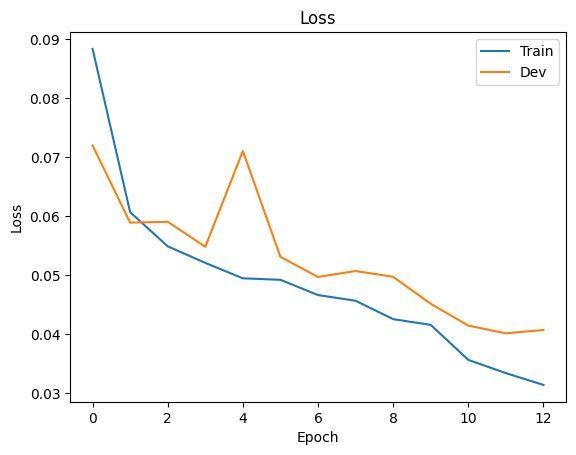

Python(20301) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20309) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20314) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20316) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20317) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20318) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20320) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20321) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20322) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20324) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Area Under Curve (AUC): 0.8938
Equal Error Rate (EER): 18.3392%
Optimal Distance Threshold: 0.5050


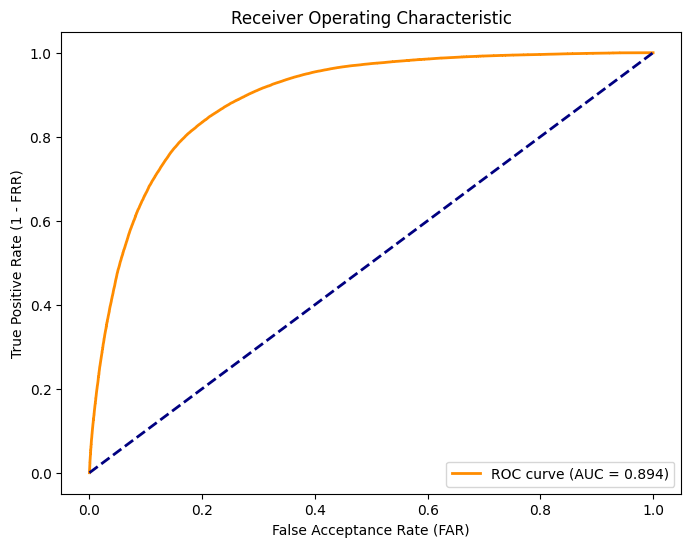

In [24]:
plot_history(history)
eer, auc_score, optimal_margin, (fpr, tpr) = evaluate_accuracy(spect_1d, dev_dual_ds)
plot_roc_curve(fpr, tpr, auc_score)

#### Saving

In [25]:
from IPython.display import FileLink

spect_1d.save("spect_1d.keras")
display(FileLink("spect_1d.keras"))

/Users/tv/venv-tf/spect_1d.keras

#### UI

In [ ]:
interface = model_ui(spect_1d, optimal_margin, length_seconds*sample_rate, sample_rate)
interface.launch()

### 2D CNN on Spectrogram (Mobilenet)

In [16]:
mobilenet = keras.Sequential([
    layers.Input(shape=audio_input_shape),
    LogMelSpectrogram(sample_rate=sample_rate),
    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),
    keras.applications.MobileNetV2(input_shape=spectro_shape[1:], include_top=False, weights=None, pooling="avg"),
    layers.Dropout(0.2),
    layers.Dense(2048),
    L2Normalize(),
])

mobilenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_mel_spectrogram_1           │ (None, 243, 64, 1)     │        32,832 │
│ (LogMelSpectrogram)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 243, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_243            │ (None, 1280)           │     2,257,408 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     2,623,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (L2Normalize)      │ (None, 2048)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,913,728 (18.74 MB)

 Trainable params: 4,846,784 (18.49 MB)

 Non-trainable params: 66,944 (261.50 KB)

#### Training

In [17]:
siamese_mobilenet = siamese_from_model(mobilenet, audio_input_shape)
siamese_mobilenet.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=TripletLoss(margin=0.2))
history = siamese_mobilenet.fit(
    train_ds,
    epochs=30,
    callbacks=callbacks,
    validation_data=dev_ds,
)

Epoch 1/30


/Users/tv/venv-tf/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 243, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


1176/1177 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - loss: 0.1133

/Users/tv/venv-tf/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [18, 243, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1659s 1s/step - loss: 0.0871 - val_loss: 0.2000 - learning_rate: 0.0010
Epoch 2/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1667s 1s/step - loss: 0.0557 - val_loss: 0.1720 - learning_rate: 0.0010
Epoch 3/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1660s 1s/step - loss: 0.0451 - val_loss: 0.1913 - learning_rate: 0.0010
Epoch 4/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1667s 1s/step - loss: 0.0410 - val_loss: 0.1650 - learning_rate: 0.0010
Epoch 5/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1662s 1s/step - loss: 0.0369 - val_loss: 0.1043 - learning_rate: 0.0010
Epoch 6/30


...

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1664s 1s/step - loss: 0.0163 - val_loss: 0.1593 - learning_rate: 0.0010
Epoch 19/30


Python(20187) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20188) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20189) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20190) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20191) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20192) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20196) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20197) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20198) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20199) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - loss: 0.0163

Python(20431) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20432) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20433) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20434) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20435) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20436) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20437) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20438) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20439) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20440) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20443) Malloc

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1686s 1s/step - loss: 0.0161 - val_loss: 0.0967 - learning_rate: 0.0010


Training History and Performance

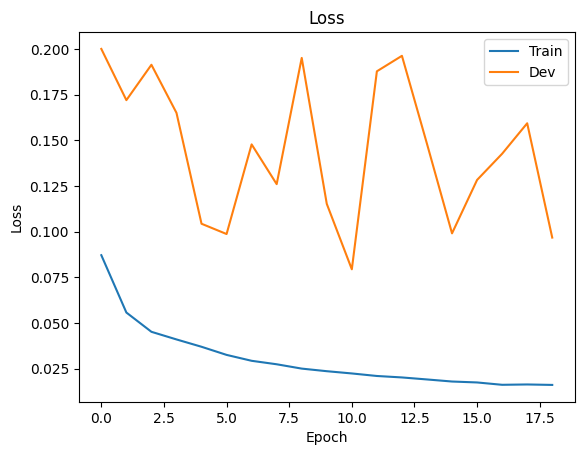

Python(20689) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20690) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20691) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20692) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20693) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20694) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20695) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20696) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20697) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(20698) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Area Under Curve (AUC): 0.8911
Equal Error Rate (EER): 18.8391%
Optimal Distance Threshold: 0.2899


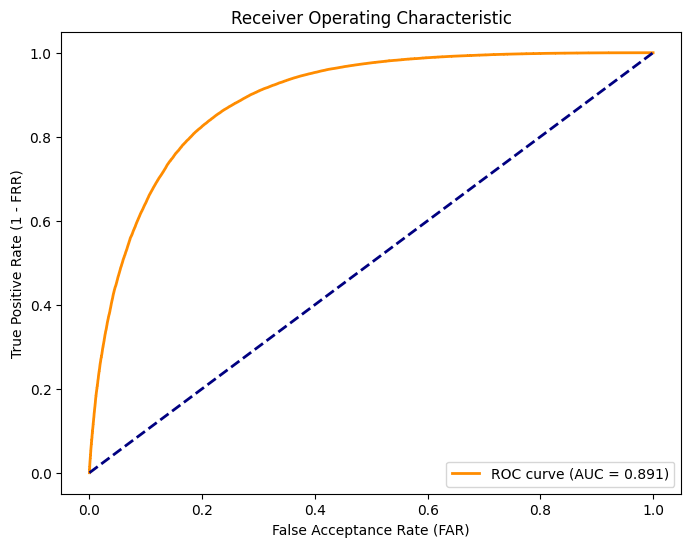

In [18]:
plot_history(history)
eer, auc_score, optimal_margin, (fpr, tpr) = evaluate_accuracy(mobilenet, dev_dual_ds)
plot_roc_curve(fpr, tpr, auc_score)

#### Saving

In [19]:
from IPython.display import FileLink

mobilenet.save("mobilenet.keras")
display(FileLink("mobilenet.keras"))

/Users/tv/venv-tf/mobilenet.keras

### 2D Bespoke CNN on Spectrogram

In [19]:
spect_2d = keras.Sequential([
  layers.Input(shape=audio_input_shape),
  LogMelSpectrogram(sample_rate=sample_rate),
  layers.Conv2D(16, 3, activation="relu", padding="same"),
  layers.Conv2D(16, 3, activation="relu", padding="same"),
  layers.BatchNormalization(),
  
  ResidualBlock2D(32),
  ResidualBlock2D(32, strides=2),
  ResidualBlock2D(32),
  ResidualBlock2D(32, strides=2),
  ResidualBlock2D(64),
  ResidualBlock2D(64, strides=2),
  ResidualBlock2D(64, strides=2),
  ResidualBlock2D(128),
  ResidualBlock2D(128, strides=2),
  ResidualBlock2D(128),
  ResidualBlock2D(256, strides=2),
  ResidualBlock2D(512, strides=2),

  layers.Flatten(),
  layers.Dropout(0.2),
  layers.Dense(2048, activation="relu"),
  L2Normalize(),
], name="cnn_2d_spectro")

spect_2d.summary()

Model: "cnn_2d_spectro"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_mel_spectrogram_3           │ (None, 243, 64, 1)     │        32,832 │
│ (LogMelSpectrogram)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 243, 64, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 243, 64, 16)    │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 243, 64, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_24             │ (None, 243, 64, 32)    │        14,816 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_25             │ (None, 122, 32, 32)    │        19,936 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_26             │ (None, 122, 32, 32)    │        18,752 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_27             │ (None, 61, 16, 32)     │        19,936 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_28             │ (None, 61, 16, 64)     │        58,304 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_29             │ (None, 31, 8, 64)      │        78,784 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_30             │ (None, 16, 4, 64)      │        78,784 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_31             │ (None, 16, 4, 128)     │       231,296 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_32             │ (None, 8, 2, 128)      │       313,216 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_33             │ (None, 8, 2, 128)      │       296,192 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_34             │ (None, 4, 1, 256)      │       921,344 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block2d_35             │ (None, 2, 1, 512)      │     3,677,696 │
│ (ResidualBlock2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             

 Total params: 7,863,632 (30.00 MB)

 Trainable params: 7,822,256 (29.84 MB)

 Non-trainable params: 41,376 (161.62 KB)

#### Training

In [20]:
siamese_spect_2d = siamese_from_model(spect_2d, audio_input_shape)
siamese_spect_2d.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=TripletLoss(margin=0.2))
history = siamese_spect_2d.fit(
    train_ds,
    epochs=30,
    callbacks=callbacks,
    validation_data=dev_ds,
)

Epoch 1/30


/Users/tv/venv-tf/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 243, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


1176/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - loss: 0.0885

/Users/tv/venv-tf/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [18, 243, 513]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3670s 3s/step - loss: 0.0678 - val_loss: 0.0587 - learning_rate: 0.0010
Epoch 2/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3696s 3s/step - loss: 0.0461 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 3/30
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0394

...

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3760s 3s/step - loss: 0.0110 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 26/30


Python(82336) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82337) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82339) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82340) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82341) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82342) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82344) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82345) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82346) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


1177/1177 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0095

Python(83577) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83578) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83579) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83580) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83581) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83582) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83583) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83584) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83585) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83586) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(83590) Malloc

1177/1177 ━━━━━━━━━━━━━━━━━━━━ 3765s 3s/step - loss: 0.0099 - val_loss: 0.0309 - learning_rate: 0.0010


Graphs

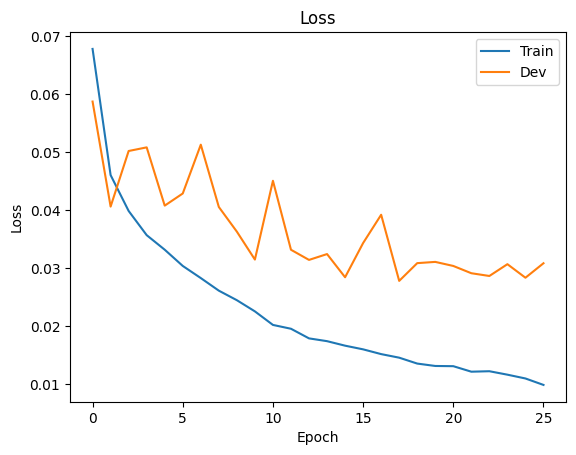

Python(84283) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84286) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84287) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84289) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84290) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84291) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84293) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84295) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(84296) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Area Under Curve (AUC): 0.9491
Equal Error Rate (EER): 11.9341%
Optimal Distance Threshold: 0.7698


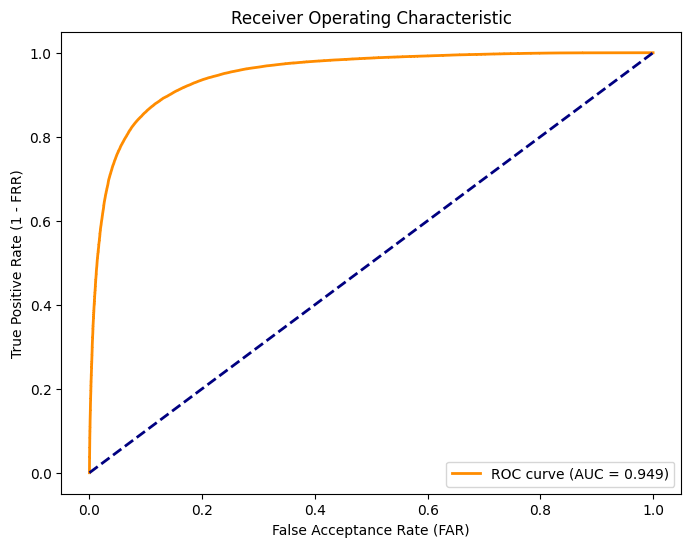

In [21]:
plot_history(history)
eer, auc_score, optimal_margin, (fpr, tpr) = evaluate_accuracy(spect_2d, dev_dual_ds)
plot_roc_curve(fpr, tpr, auc_score)

#### Saving

In [22]:
from IPython.display import FileLink

spect_2d.save("spect_2d.keras")
display(FileLink("spect_2d.keras"))

/Users/tv/venv-tf/spect_2d.keras

## Interface (Gradio)